<a href="https://colab.research.google.com/github/tanmaynolkha/DSML_GRRAS/blob/main/Customer_segmention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving customer_segmentation.csv to customer_segmentation.csv


In [2]:
import pandas as pd
import numpy as np


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("customer_segmentation.csv")

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [8]:
df.shape


(2240, 29)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [13]:
df.isna().sum().sum()

np.int64(24)

In [15]:
df=df.dropna()

In [16]:
df.isna().sum().sum()

np.int64(0)

In [17]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [18]:
df["Education"].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [22]:
df["Marital_Status"].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [23]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [25]:
df["Age"]=2025-df["Year_Birth"]

In [26]:
df["Age"]

,Age
0,68
1,71
2,60
3,41
4,44
...,...
2235,58
2236,79
2237,44
2238,69


In [27]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,41
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,44


In [28]:
df["Total_Childern"]=df["Kidhome"]+df["Teenhome"]

In [29]:
df["Total_Childern"]

,Total_Childern
0,0
1,2
2,0
3,1
4,1
...,...
2235,1
2236,3
2237,0
2238,1


In [30]:
spend_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

In [31]:
df["Total_Spending"]=df[spend_cols].sum(axis=1)

In [32]:
df["Total_Spending"]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [33]:
df["Customer_Since"]=(pd.Timestamp("today")-df["Dt_Customer"]).dt.days

In [34]:
df["Customer_Since"]

,Customer_Since
0,5133
1,4583
2,4782
3,4609
4,4631
...,...
2235,4851
2236,4489
2237,4625
2238,4626


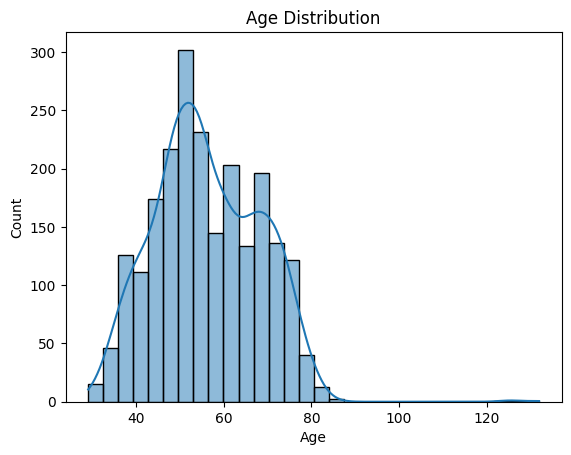

In [35]:
sns.histplot(df["Age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

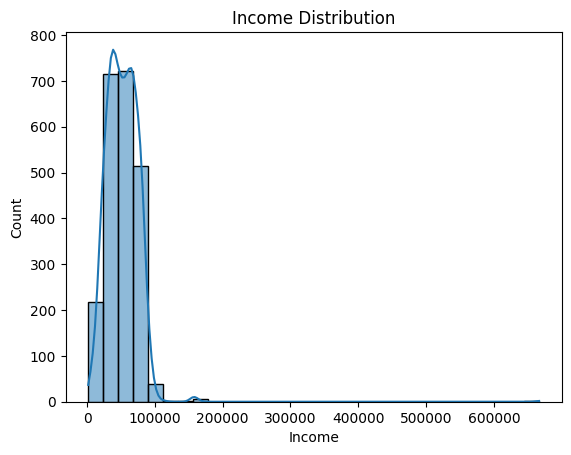

In [36]:
sns.histplot(df["Income"],bins=30,kde=True)
plt.title("Income Distribution")
plt.show()

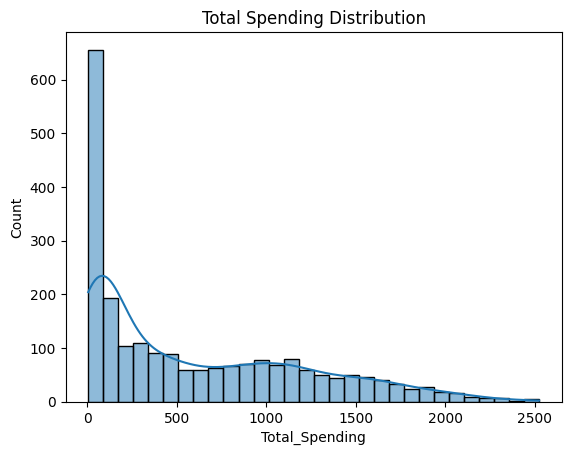

In [37]:
sns.histplot(df["Total_Spending"],bins=30,kde=True)
plt.title("Total Spending Distribution")
plt.show()

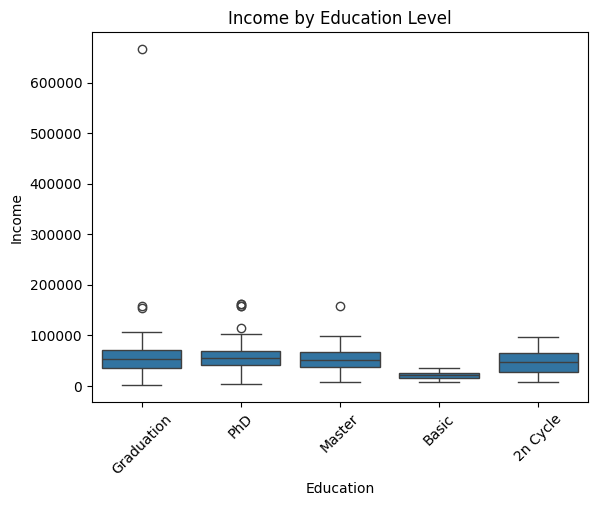

In [39]:
sns.boxplot(x="Education",y="Income",data=df)
plt.xticks(rotation=45)
plt.title("Income by Education Level")
plt.show()

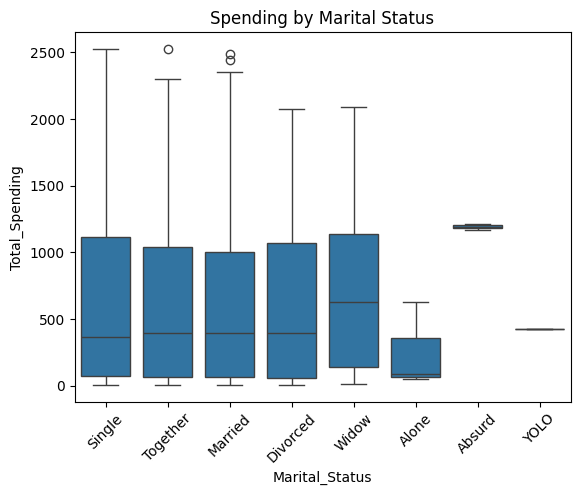

In [40]:
sns.boxplot(x="Marital_Status",y="Total_Spending",data=df)
plt.xticks(rotation=45)
plt.title("Spending by Marital Status")
plt.show()
#

In [46]:
corr = df[["Income","Age","Recency","Total_Spending","NumWebPurchases","NumStorePurchases"]].corr()


In [47]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
0,58138.0,68,58,1617,8,4
1,46344.0,71,38,27,1,2
2,71613.0,60,26,776,8,10
3,26646.0,41,26,53,2,4
4,58293.0,44,94,422,5,6
...,...,...,...,...,...,...
2235,61223.0,58,46,1341,9,4
2236,64014.0,79,56,444,8,5
2237,56981.0,44,91,1241,2,13
2238,69245.0,69,8,843,6,10


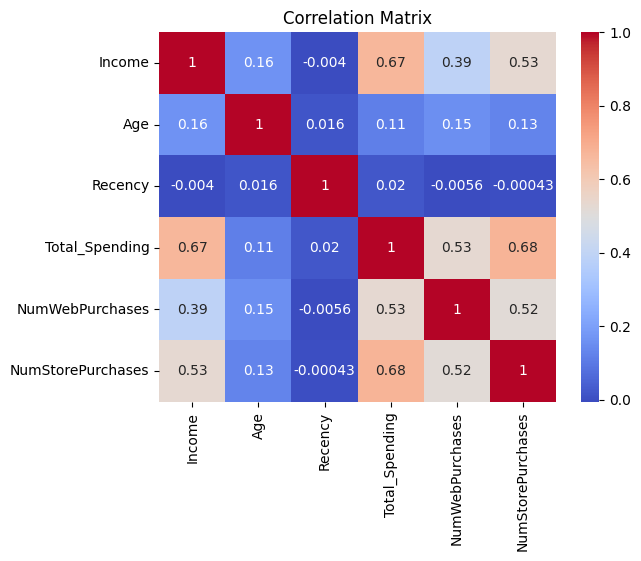

In [51]:
sns.heatmap(corr.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

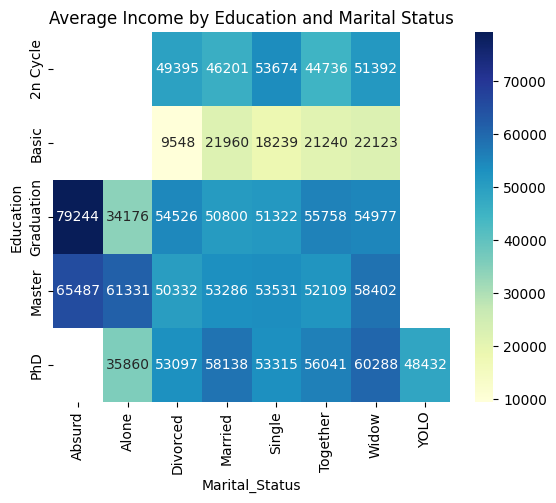

In [53]:
pivot_income = df.pivot_table(index='Education', columns='Marital_Status', values='Income', aggfunc='mean')
sns.heatmap(pivot_income, annot=True,fmt=".0f", cmap='YlGnBu')
plt.title('Average Income by Education and Marital Status')
plt.show()

In [54]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)

In [55]:
group1

,Total_Spending
Education,
PhD,676.733888
Graduation,621.686380
Master,609.767123
2n Cycle,494.930000
Basic,81.796296


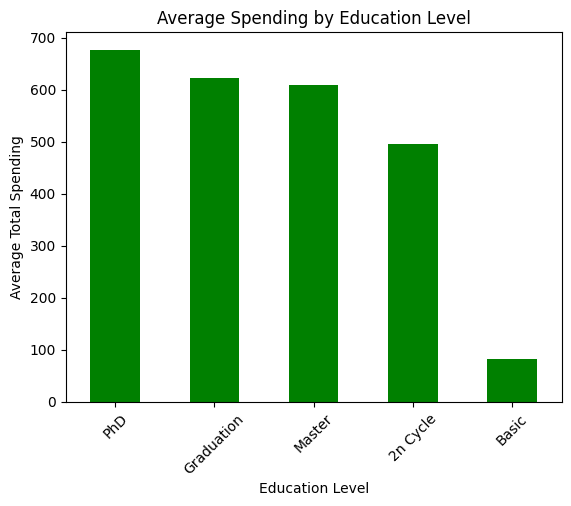

In [56]:
group1.plot(kind="bar",color="green")
plt.title("Average Spending by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

In [57]:
df["AcceptedAny"]=df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]].sum(axis=1)

In [59]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [68]:
df["AcceptedAny"]=df["AcceptedAny"].apply(lambda x:1 if x > 0 else 0)

In [73]:
df["AcceptedAny"].unique()

array([1, 0])

In [74]:
group2=df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)

In [75]:
group2

,AcceptedAny
Marital_Status,
Absurd,0.500000
YOLO,0.500000
Widow,0.342105
Alone,0.333333
Single,0.312102
Divorced,0.297414
Married,0.252042
Together,0.251309


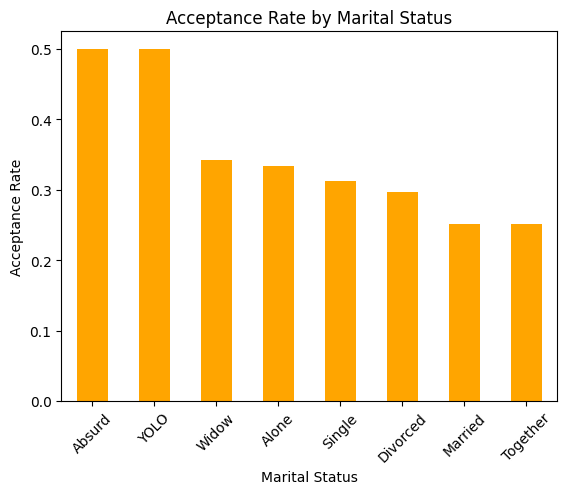

In [93]:
group2.plot(kind="bar",color="orange")
plt.title("Acceptance Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation=45)
plt.show()

In [77]:
bins=[18,30,40,50,60,70,90]

In [78]:
labels=["18-29","30-39","40-49","50-59","60-69","70+"]

In [81]:
df["AgeGroup"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [82]:
df["AgeGroup"]

,AgeGroup
0,60-69
1,70+
2,50-59
3,40-49
4,40-49
...,...
2235,50-59
2236,70+
2237,40-49
2238,60-69


In [83]:
group3=df.groupby("AgeGroup")["Income"].mean().sort_values(ascending=False)

/tmp/ipykernel_3767/330173040.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3=df.groupby("AgeGroup")["Income"].mean().sort_values(ascending=False)


In [84]:
group3


,Income
AgeGroup,
70+,58944.316294
60-69,56200.827887
50-59,50812.913303
40-49,49224.877034
18-29,46658.000000
30-39,46283.028302


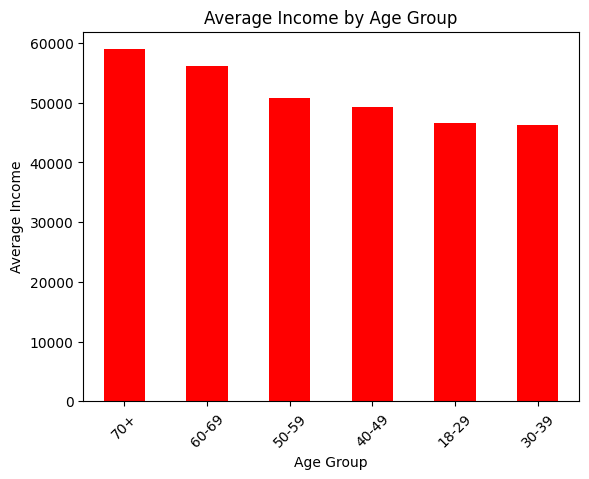

In [85]:
group3.plot(kind="bar",color="red")
plt.title("Average Income by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Income")
plt.xticks(rotation=45)
plt.show()

In [86]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Childern,Total_Spending,Customer_Since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,68,0,1617,5133,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,71,2,27,4583,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,60,0,776,4782,0,50-59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,41,1,53,4609,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,44,1,422,4631,0,40-49


In [87]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Childern', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [ ]:
Age - Income - Total_Spending -NumWebPurchases - NumStorePurchases - NumWebVisitsMonth - Recency

In [89]:
features=["Age","Income","Total_Spending","NumWebPurchases","NumStorePurchases","NumWebVisitsMonth","Recency"]

In [90]:
x=df[features].copy()

In [91]:
x

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5,46
2236,79,64014.0,444,8,5,7,56
2237,44,56981.0,1241,2,13,6,91
2238,69,69245.0,843,6,10,3,8


In [92]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [94]:
x_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]])

In [95]:
from sklearn.cluster import KMeans

In [96]:
wcss=[]

In [97]:
for i in range(2,10):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(x_scaled)
  wcss.append(kmeans.inertia_)

In [98]:
wcss

[10218.670773072332,
 9007.783808892209,
 8158.801654022348,
 7648.575618989701,
 7227.988422792308,
 6620.05322471522,
 6426.684266366194,
 6220.013264431899]

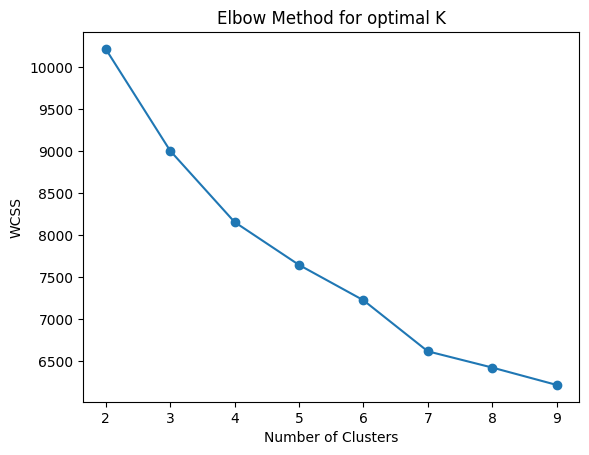

In [99]:
plt.plot(range(2,10),wcss,marker="o")
plt.title("Elbow Method for optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [101]:
kmeans = KMeans(n_clusters=6)
df["Cluster"]=kmeans.fit_predict(x_scaled)

In [103]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_Childern,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,68,0,1617,5133,1,60-69,2
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,71,2,27,4583,0,70+,1
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,60,0,776,4782,0,50-59,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,41,1,53,4609,0,40-49,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,44,1,422,4631,0,40-49,5


In [104]:
cluster_summary=df.groupby("Cluster")[features].mean()

In [105]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,61.864353,56122.283912,678.640379,6.744479,6.646688,6.277603,25.274448
1,50.908397,32146.793893,86.772901,1.912214,3.030534,6.624046,26.393130
2,57.414062,62917.332031,1055.484375,7.781250,9.156250,5.964844,69.542969
3,69.810345,74094.575862,1179.175862,4.341379,8.262069,2.355172,53.058621
4,46.032787,79336.570492,1318.462295,4.540984,8.491803,2.534426,45.872131
5,55.770992,36931.883588,134.322519,2.437023,3.492366,6.379771,75.551527


In [107]:
df["Cluster"].value_counts()

,count
Cluster,
1,524
5,524
0,317
4,305
3,290
2,256


In [109]:
from sklearn.decomposition import PCA
pca =PCA(n_components=2)
x_pca =pca.fit_transform(x_scaled)
df["PCA1"],df["PCA2"] = x_pca[:,0],x_pca[:,1]

In [110]:
x_pca

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]])

In [112]:
df["PCA1"]
df["PCA2"]

,PCA2
0,-0.211760
1,0.269839
2,-1.014161
3,-0.704928
4,1.235265
...,...
2235,-0.535766
2236,-0.141328
2237,1.150570
2238,-1.160737


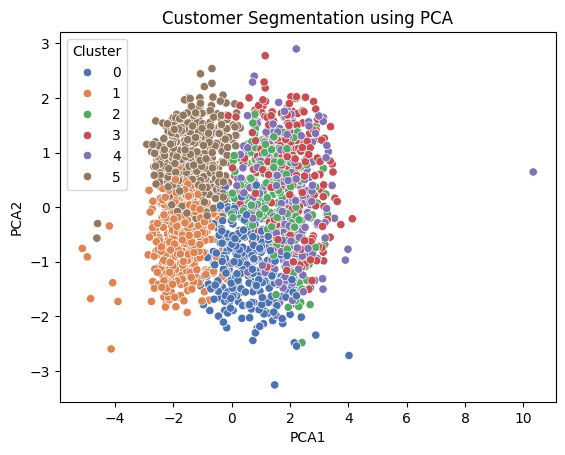

In [114]:
sns.scatterplot(x="PCA1",y="PCA2",hue="Cluster",data=df,palette="deep")
plt.title("Customer Segmentation using PCA")
plt.show()

In [115]:
import joblib
joblib.dump(kmeans,"kmeans_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']